# $Proyecto$ $Final$ $-$ $Inteligencia$ $Artificial$ $01$
----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


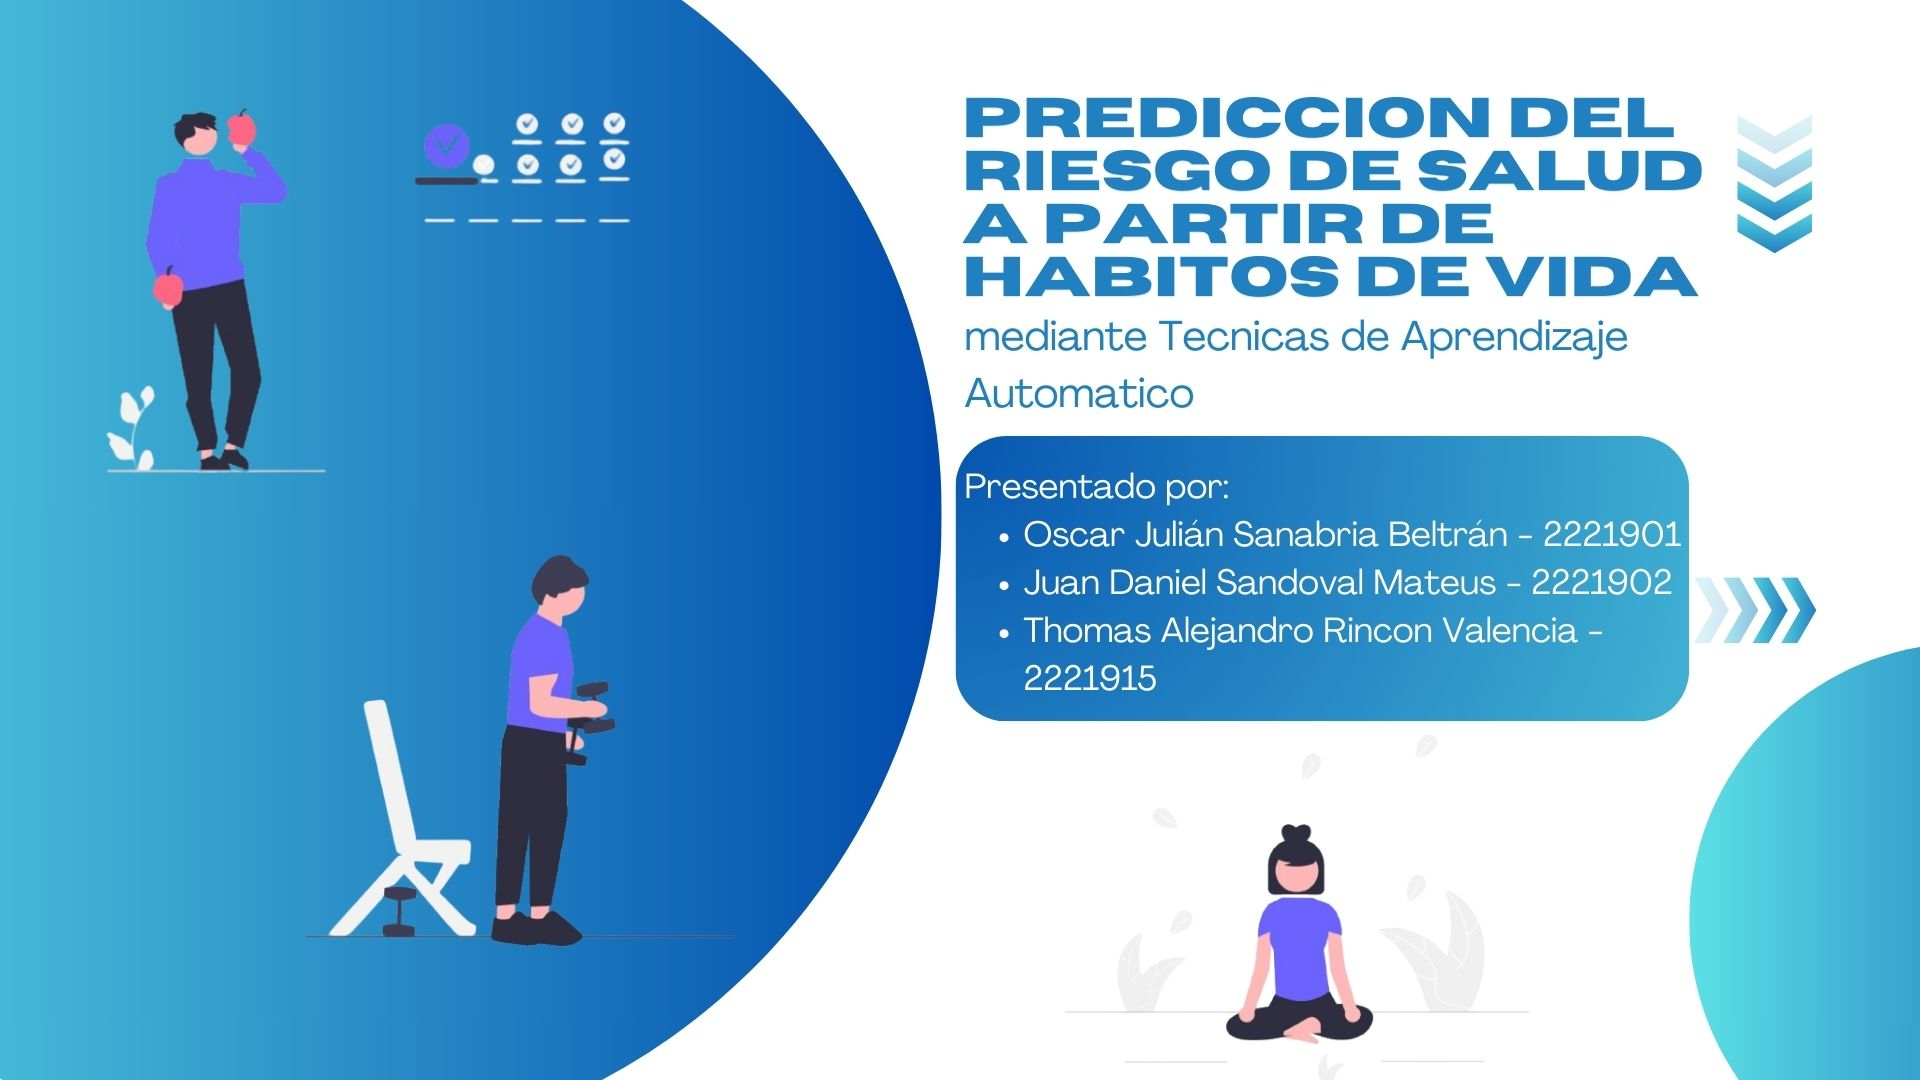

In [ ]:
from IPython.display import Image
Image(filename='/content/drive/MyDrive/Mis clases/Inteligencia Artificial I/White and Blue Team Project Presentation.jpg.jpeg', width=500, height=300) # Puedes ajustar width y height aquí.

# $Prediccion$ $del$ $Riesgo$ $de$ $Salud$ $a$ $partir$ $de$ $Habitos$ $de$ $Vida$ $mediante$ $Tecnicas$ $de$ $Aprendizaje$ $Automatico$
**Integrantes**

*   Oscar Julián Sanabria Beltrán - 2221901
*   Juan Daniel Sandoval Mateus - 2221902
*   Thomas Alejandro Rincon Valencia  - 2221915



-----
## $Primera$ $Entrega$
###1. $El$ $dataset$

In [ ]:
# Importacion de las librerias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import tensorflow as tf

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import export_graphviz
from IPython.display import Image
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.tree import DecisionTreeClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Carga del dataset
url = "/content/Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv"
df = pd.read_csv(url)

In [ ]:
# Imprimimos el dataset
df

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,42,75,187,medium,7.2,low,no,no,yes,driver,21.4,low
4996,39,86,183,low,7.4,low,no,no,yes,engineer,25.7,high
4997,48,56,194,none,7.2,high,yes,yes,yes,engineer,14.9,high
4998,34,109,148,medium,9.9,medium,no,no,yes,doctor,49.8,low


In [ ]:
# Descripcion estadistica de las variables cuantitativas
df.describe()

,age,weight,height,sleep,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,48.805600,77.359200,171.933200,6.997060,26.84388
std,17.906991,18.714567,15.822225,1.432849,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


In [ ]:
df.columns

Index(['age', 'weight', 'height', 'exercise', 'sleep', 'sugar_intake',
       'smoking', 'alcohol', 'married', 'profession', 'bmi', 'health_risk'],
      dtype='object')

In [ ]:
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [ ]:
df.shape

(5000, 12)

In [ ]:
# Columnas con las que contamos:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   married       5000 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


In [ ]:
df.isnull().sum()

,0
age,0
weight,0
height,0
exercise,0
sleep,0
sugar_intake,0
smoking,0
alcohol,0
married,0
profession,0


NameError: name 'df_original' is not defined

# $Graficas$

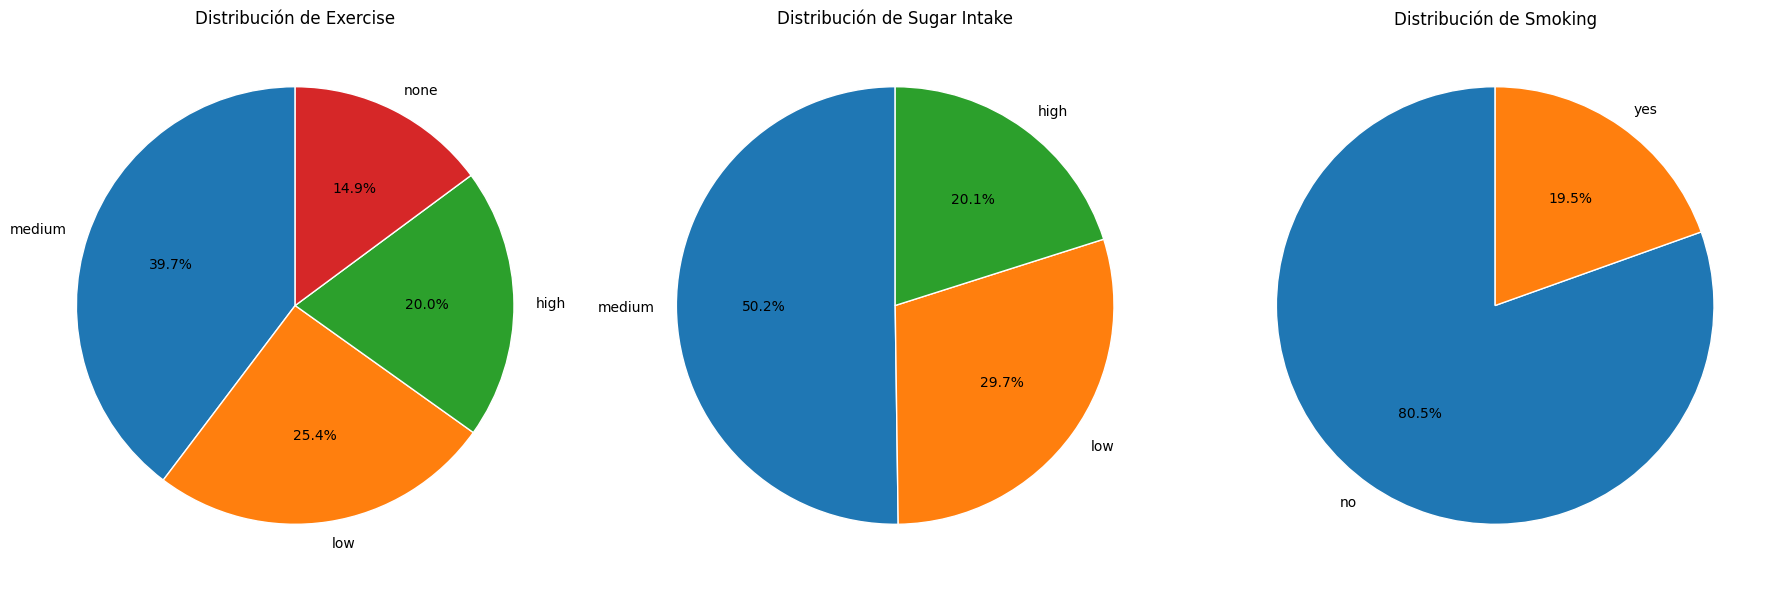

In [ ]:
cols = ['exercise', 'sugar_intake', 'smoking']
titulos = ['Exercise', 'Sugar Intake', 'Smoking']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(cols):
    conteo = df[col].value_counts()

    axes[i].pie(
        conteo.values,
        labels=conteo.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white'}
    )
    axes[i].set_title(f'Distribución de {titulos[i]}')

plt.tight_layout()
plt.show()

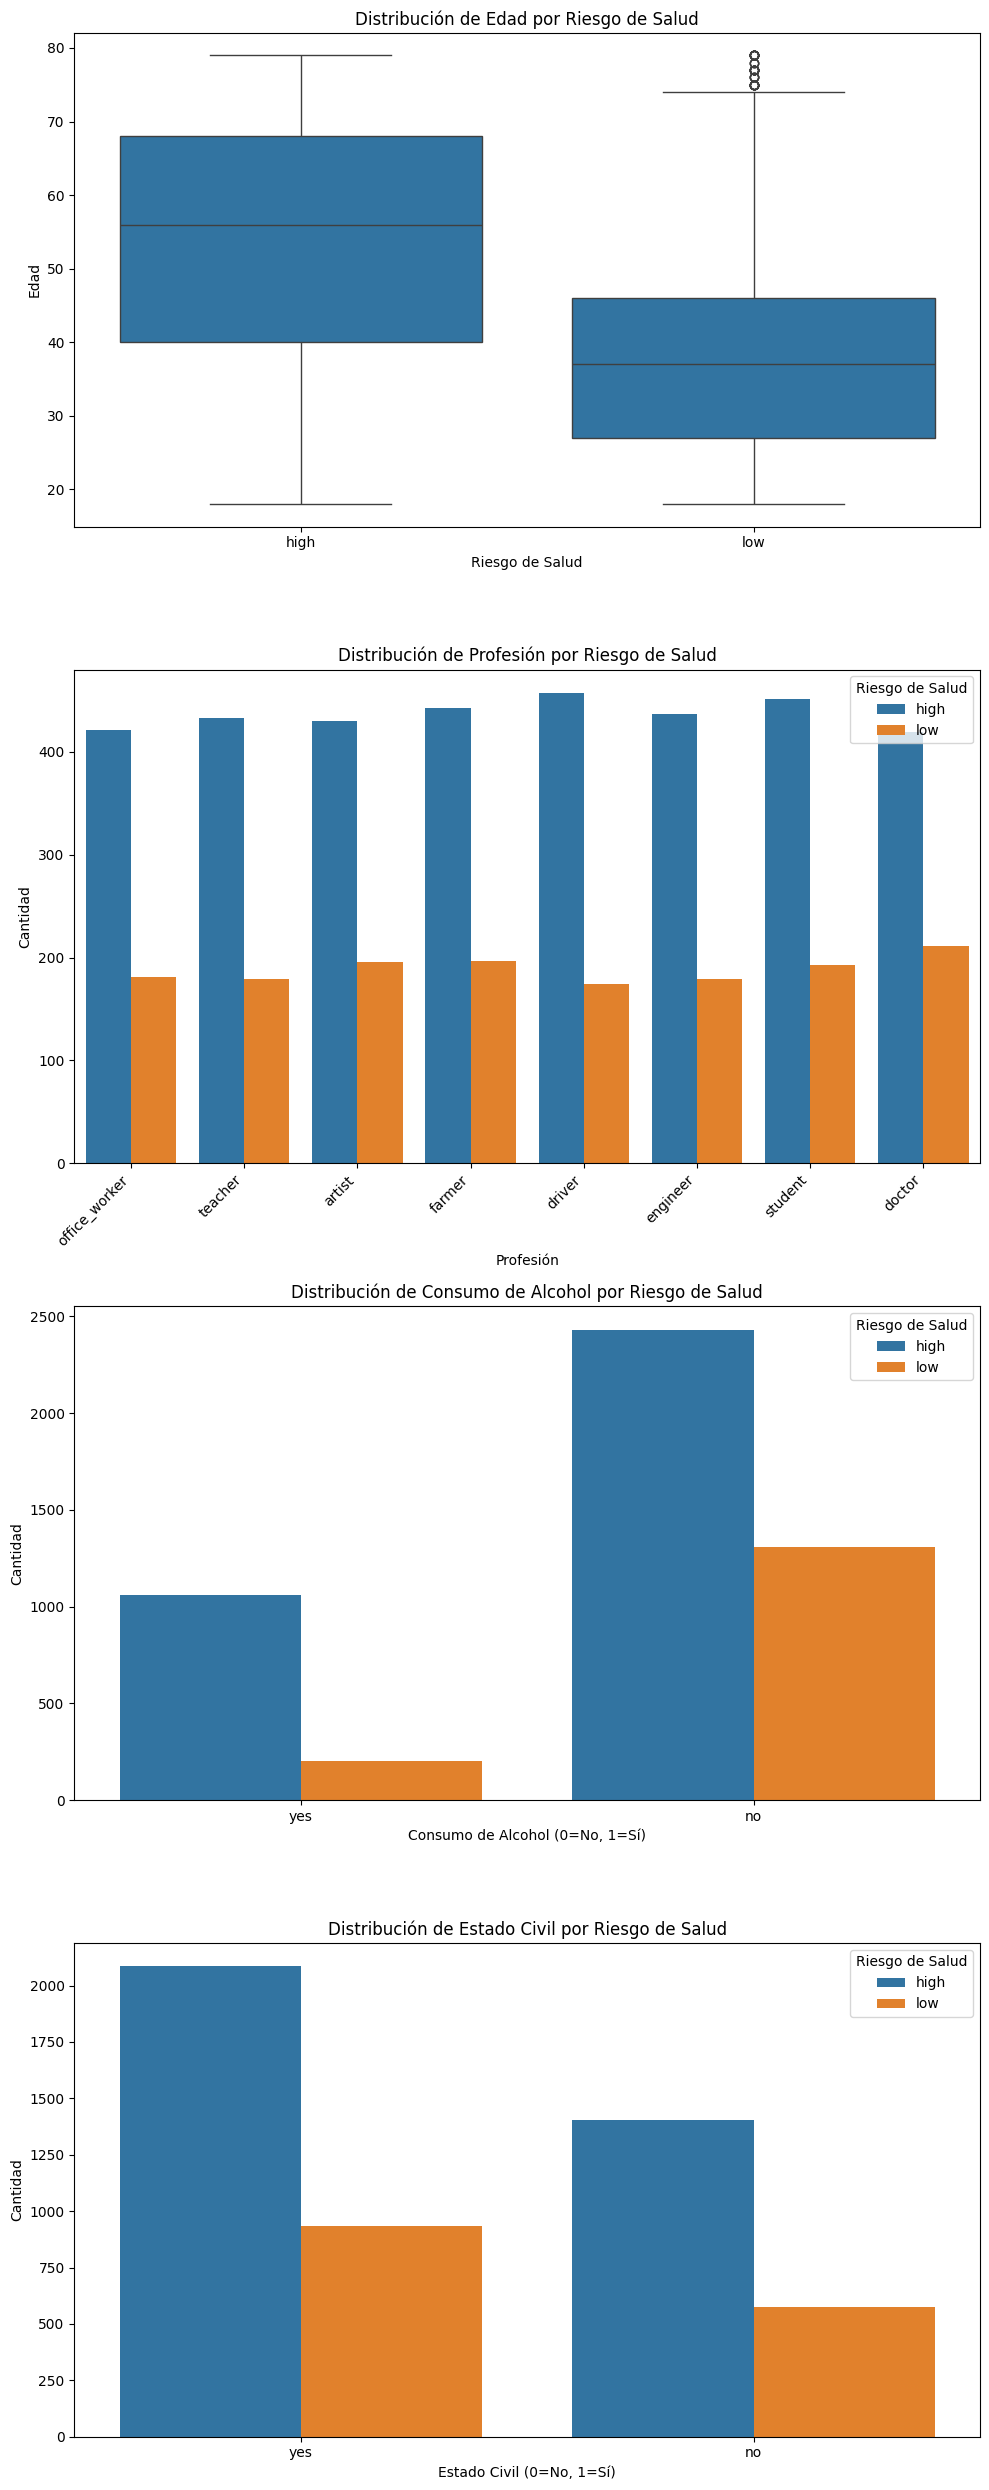

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(10, 25))

# Gráfica de Edad vs Riesgo de Salud
sns.boxplot(x='health_risk', y='age', data=df, ax=axes[0])
axes[0].set_title('Distribución de Edad por Riesgo de Salud')
axes[0].set_xlabel('Riesgo de Salud')
axes[0].set_ylabel('Edad')

# Gráfica de Profesión vs Riesgo de Salud
sns.countplot(x='profession', hue='health_risk', data=df, ax=axes[1])
axes[1].set_title('Distribución de Profesión por Riesgo de Salud')
axes[1].set_xlabel('Profesión')
axes[1].set_ylabel('Cantidad')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right') # Corregido para rotar y alinear las etiquetas
axes[1].legend(title='Riesgo de Salud')

# Gráfica de Consumo de Alcohol vs Riesgo de Salud
sns.countplot(x='alcohol', hue='health_risk', data=df, ax=axes[2])
axes[2].set_title('Distribución de Consumo de Alcohol por Riesgo de Salud')
axes[2].set_xlabel('Consumo de Alcohol (0=No, 1=Sí)')
axes[2].set_ylabel('Cantidad')
axes[2].legend(title='Riesgo de Salud')

# Gráfica de Estado Civil vs Riesgo de Salud
sns.countplot(x='married', hue='health_risk', data=df, ax=axes[3])
axes[3].set_title('Distribución de Estado Civil por Riesgo de Salud')
axes[3].set_xlabel('Estado Civil (0=No, 1=Sí)')
axes[3].set_ylabel('Cantidad')
axes[3].legend(title='Riesgo de Salud')

plt.tight_layout()
plt.show()

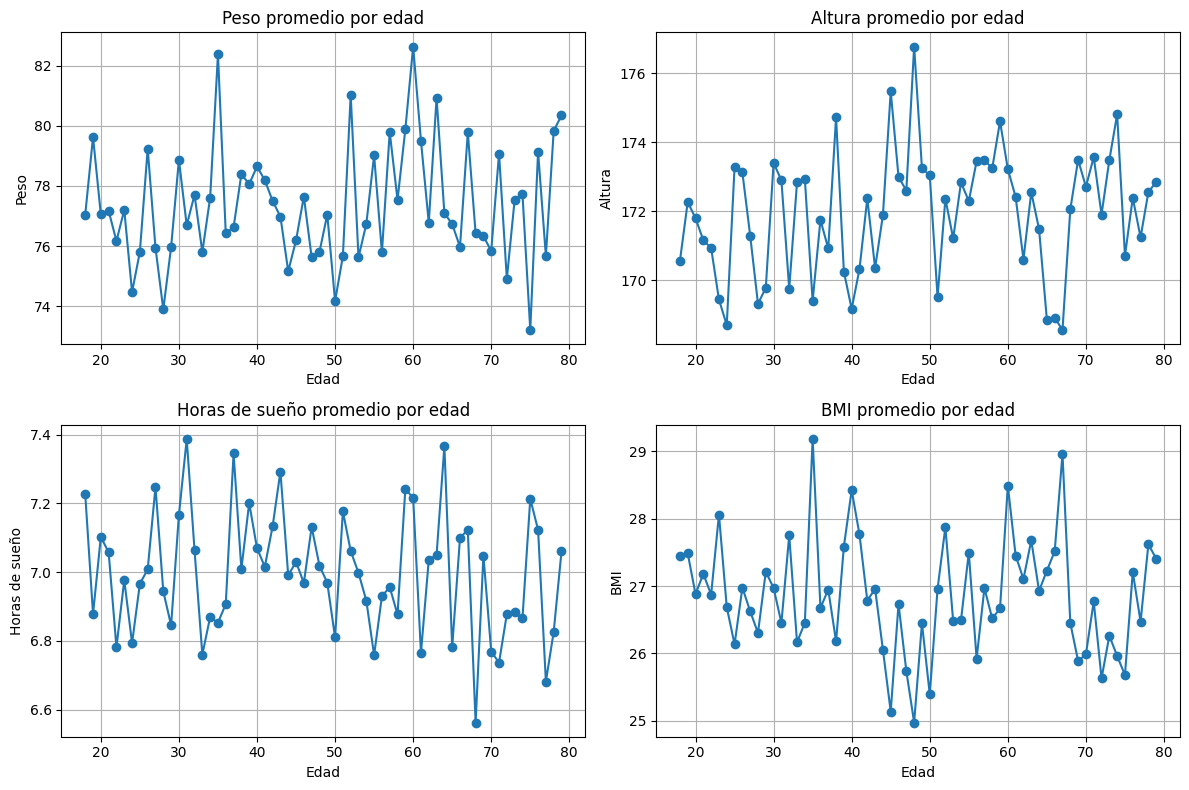

In [ ]:
# Agrupar por edad y calcular el promedio de las variables numéricas
age_group = df.groupby('age')[['weight', 'height', 'sleep', 'bmi']].mean()

# Lista de variables
labels = {
    'weight': 'Peso',
    'height': 'Altura',
    'sleep': 'Horas de sueño',
    'bmi': 'BMI'
}

# Crear figura con 4 subgráficas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # convierte la matriz de ejes en una lista

# Recorrer variables y graficar
for ax, var in zip(axes, labels.keys()):
    ax.plot(age_group.index, age_group[var], marker='o')
    ax.set_title(f"{labels[var]} promedio por edad")
    ax.set_xlabel("Edad")
    ax.set_ylabel(labels[var])
    ax.grid(True)

plt.tight_layout()
plt.show()

# $Segunda$ $entrega$
## $Preparacion$ $de$ $los$ $datos$

In [ ]:
#Dataset antes de las transformaciones
df

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,42,75,187,medium,7.2,low,no,no,yes,driver,21.4,low
4996,39,86,183,low,7.4,low,no,no,yes,engineer,25.7,high
4997,48,56,194,none,7.2,high,yes,yes,yes,engineer,14.9,high
4998,34,109,148,medium,9.9,medium,no,no,yes,doctor,49.8,low


In [ ]:
df.isnull().sum()

,0
age,0
weight,0
height,0
exercise,0
sleep,0
sugar_intake,0
smoking,0
alcohol,0
married,0
profession,0


In [ ]:
# Mapear 'yes' a 1 y 'no' a 0 para las columnas especificadas

df_original = df.copy()

df['smoking'] = df['smoking'].replace({'yes': 1, 'no': 0})
df['alcohol'] = df['alcohol'].replace({'yes': 1, 'no': 0})
df['married'] = df['married'].replace({'yes': 1, 'no': 0})

/tmp/ipykernel_2221/2771769191.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoking'] = df['smoking'].replace({'yes': 1, 'no': 0})
/tmp/ipykernel_2221/2771769191.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['alcohol'] = df['alcohol'].replace({'yes': 1, 'no': 0})
/tmp/ipykernel_2221/2771769191.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavio

In [ ]:
#Transformacion adicional - exercise y sugar_intake.
# Ordinal encoding
df['exercise'] = df['exercise'].map({'none': 0, 'low': 1, 'medium': 2, 'high': 3})
df['sugar_intake'] = df['sugar_intake'].map({'low': 0, 'medium': 1, 'high': 2})

In [ ]:
df['health_risk'] = df['health_risk'].map({'low': 0, 'high': 1})


In [ ]:
d = df.drop(columns=['profession'])


In [ ]:
d

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,bmi,health_risk
0,56,67,195,1,6.1,1,1,1,1,17.6,1
1,69,76,170,3,6.9,2,0,0,0,26.3,1
2,46,106,153,3,6.6,0,1,0,0,45.3,1
3,32,54,186,2,8.5,1,0,0,0,15.6,0
4,60,98,195,3,8.0,0,0,0,1,25.8,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,42,75,187,2,7.2,0,0,0,1,21.4,0
4996,39,86,183,1,7.4,0,0,0,1,25.7,1
4997,48,56,194,0,7.2,2,1,1,1,14.9,1
4998,34,109,148,2,9.9,1,0,0,1,49.8,0


In [ ]:
# Hacemos la separacion
X = d.drop(columns=['health_risk'])
y = d['health_risk']


In [ ]:
#features
X.columns

Index(['age', 'weight', 'height', 'exercise', 'sleep', 'sugar_intake',
       'smoking', 'alcohol', 'married', 'bmi'],
      dtype='object')

In [ ]:
# Shuffle del dataset completo antes de partir
df_shuffled = d.sample(frac=1, random_state=42).reset_index(drop=True)

# Volver a separar X y y tras el shuffle
X = df_shuffled.drop(columns=['health_risk'])
y = df_shuffled['health_risk']
d.head()


,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,bmi,health_risk
0,56,67,195,1,6.1,1,1,1,1,17.6,1
1,69,76,170,3,6.9,2,0,0,0,26.3,1
2,46,106,153,3,6.6,0,1,0,0,45.3,1
3,32,54,186,2,8.5,1,0,0,0,15.6,0
4,60,98,195,3,8.0,0,0,0,1,25.8,1


$Hacemos$  $la$  $particion$

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=21,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} filas")  # ~4000
print(f"Prueba:        {X_test.shape[0]} filas")   # ~1000


Entrenamiento: 4000 filas
Prueba:        1000 filas


# Gaussian naive bayes

Accuracy: 0.85

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.72      0.81      0.77       302
           1       0.91      0.87      0.89       698

    accuracy                           0.85      1000
   macro avg       0.82      0.84      0.83      1000
weighted avg       0.86      0.85      0.85      1000



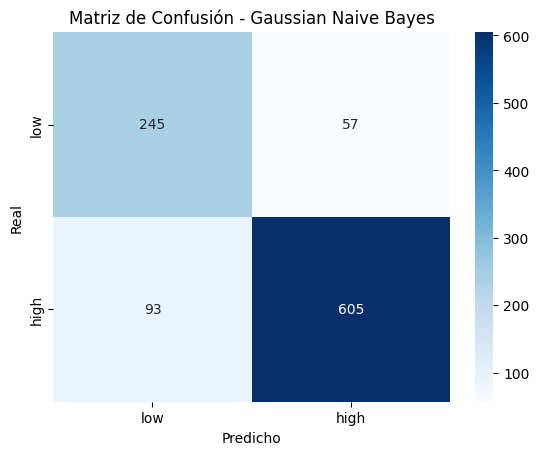

In [ ]:
# Crear y entrenar el modelo
modelo_gnb = GaussianNB()
modelo_gnb.fit(X_train, y_train)   # Aprende con el 80%

# Predecir sobre el 20% que nunca vio
y_pred = modelo_gnb.predict(X_test)

# Evaluar resultados
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['low', 'high'],
            yticklabels=['low', 'high'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Gaussian Naive Bayes')
plt.show()

# **1. $Decision$ $Tree$ $Classifier$**

In [ ]:
print(X.shape)
print(y.shape)
print(y.value_counts())

(5000, 10)
(5000,)
health_risk
1    3490
0    1510
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=21,
    stratify=y
)

In [ ]:
def tpr(est, X, y): # TPR: qué tan bien detecta los casos high. 1
    p = est.predict(X)
    return np.mean(p[y == 1] == y[y == 1])

def tnr(est, X, y): # TNR: qué tan bien detecta los casos low. 0
    p = est.predict(X)
    return np.mean(p[y == 0] == y[y == 0])

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 10)
X_test: (1000, 10)
y_train: (4000,)
y_test: (1000,)


# Pruebas
Vamos a probar profundidades de 1 a 20. Usaremos cv=10, siendo la cantidad de k folders más razonable para nuestro dataset de 5000 filas.

In [ ]:
resultados = []

for depth in range(1, 21):
    modelo = DecisionTreeClassifier(
        max_depth=depth, #valores a evaluar
        random_state=21
    )

# Aquí se hace validación cruzada de 10 folds sobre el conjunto de entrenamiento.

# Es decir que X_train se divide en 10 partes.
    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=10,
        scoring={
            'accuracy': 'accuracy',
            'recall_high': 'recall',
            'balanced_accuracy': 'balanced_accuracy'
        }
    )

    resultados.append({
        'max_depth': depth, #Profundidad probada
        'accuracy_mean': scores['test_accuracy'].mean(), #Accuracy promedio en los 10 folds
        'accuracy_std': scores['test_accuracy'].std(), # Qué tanto varió el accuracy entre folds
        'recall_high_mean': scores['test_recall_high'].mean(), # Qué tan bien detectó la clase high
        'balanced_accuracy_mean': scores['test_balanced_accuracy'].mean() #Promedio equilibrado entre las clases
    })

resultados_df = pd.DataFrame(resultados)
resultados_df.sort_values(by='accuracy_mean', ascending=False).head(5) #Ordenamos los resultados

,max_depth,accuracy_mean,accuracy_std,recall_high_mean,balanced_accuracy_mean
6,7,0.99575,0.001953,0.996062,0.995548
7,8,0.99500,0.003873,0.994627,0.995244
9,10,0.99500,0.003708,0.994986,0.995010
10,11,0.99500,0.003708,0.994986,0.995010
16,17,0.99500,0.003708,0.994986,0.995010


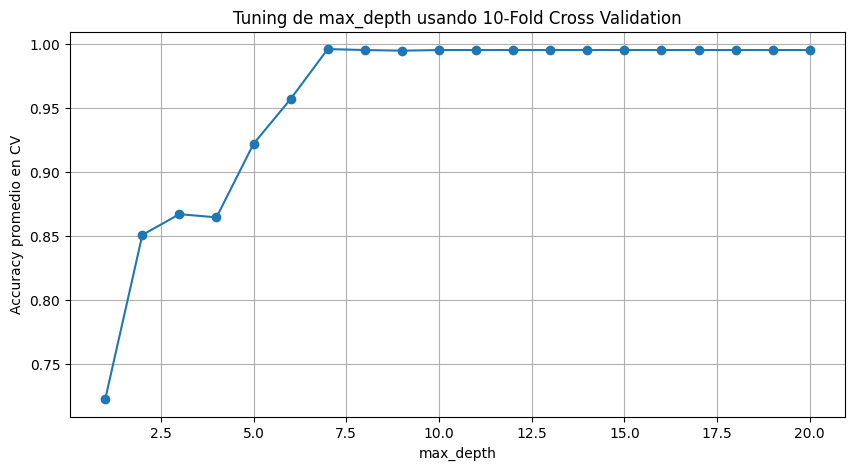

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(resultados_df['max_depth'], resultados_df['accuracy_mean'], marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy promedio en CV')
plt.title('Tuning de max_depth usando 10-Fold Cross Validation')
plt.grid(True)
plt.show()

In [ ]:
mejor_fila = resultados_df.loc[resultados_df['accuracy_mean'].idxmax()]
mejor_depth = int(mejor_fila['max_depth'])

print("Mejor max_depth:", mejor_depth)
print("Accuracy promedio CV:", mejor_fila['accuracy_mean'])
print("Desviación estándar:", mejor_fila['accuracy_std'])
print("Balanced accuracy promedio:", mejor_fila['balanced_accuracy_mean'])

Mejor max_depth: 7
Accuracy promedio CV: 0.9957499999999999
Desviación estándar: 0.0019525624189766716
Balanced accuracy promedio: 0.9955484516298299


# Probamos el clasificador

In [ ]:
modelo_final = DecisionTreeClassifier(
    max_depth=mejor_depth,
    random_state=21
)

modelo_final.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, random_state=21)

In [ ]:
y_pred = modelo_final.predict(X_test) #Probamos y evaluamos

acc_test = accuracy_score(y_test, y_pred)

print("Accuracy en test:", acc_test)
print("TPR en test:", tpr(modelo_final, X_test, y_test))
print("TNR en test:", tnr(modelo_final, X_test, y_test))

Accuracy en test: 0.994
TPR en test: 0.995702005730659
TNR en test: 0.9900662251655629


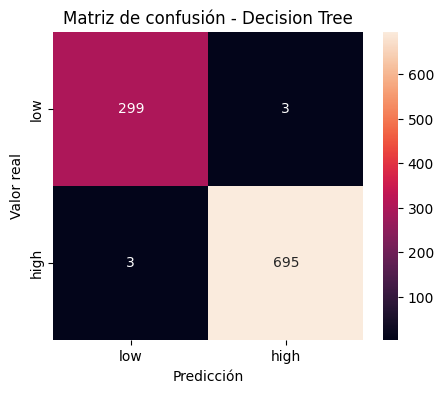

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['low', 'high'],
    yticklabels=['low', 'high']
)

plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - Decision Tree')
plt.show()

In [ ]:
print("TPR en test:", tpr(modelo_final, X_test, y_test))
print("TNR en test:", tnr(modelo_final, X_test, y_test))

TPR en test: 0.995702005730659
TNR en test: 0.9900662251655629


De los 302 pacientes/personas que realmente eran low o tenian bajo riesgo de salud, el modelo clasificó correctamente los 302.

De los 698 casos que realmente eran high o SÍ tenían riesgo de salud, el modelo clasificó correctamente 692 y se equivocó en 6.

El modelo Decision Tree obtuvo un accuracy de 0.994 en el conjunto de prueba, lo que indica que clasificó correctamente el 99.4% de los registros. La matriz de confusión muestra que todos los casos de riesgo bajo fueron clasificados correctamente, mientras que de los 698 casos de riesgo alto, 692 fueron clasificados correctamente y 6 fueron clasificados erróneamente como riesgo bajo. El TPR fue de 0.9914, indicando una alta capacidad para detectar casos de riesgo alto, y el TNR fue de 1.0, indicando una clasificación perfecta de los casos de riesgo bajo. En general, el árbol presenta un desempeño muy alto para este dataset.

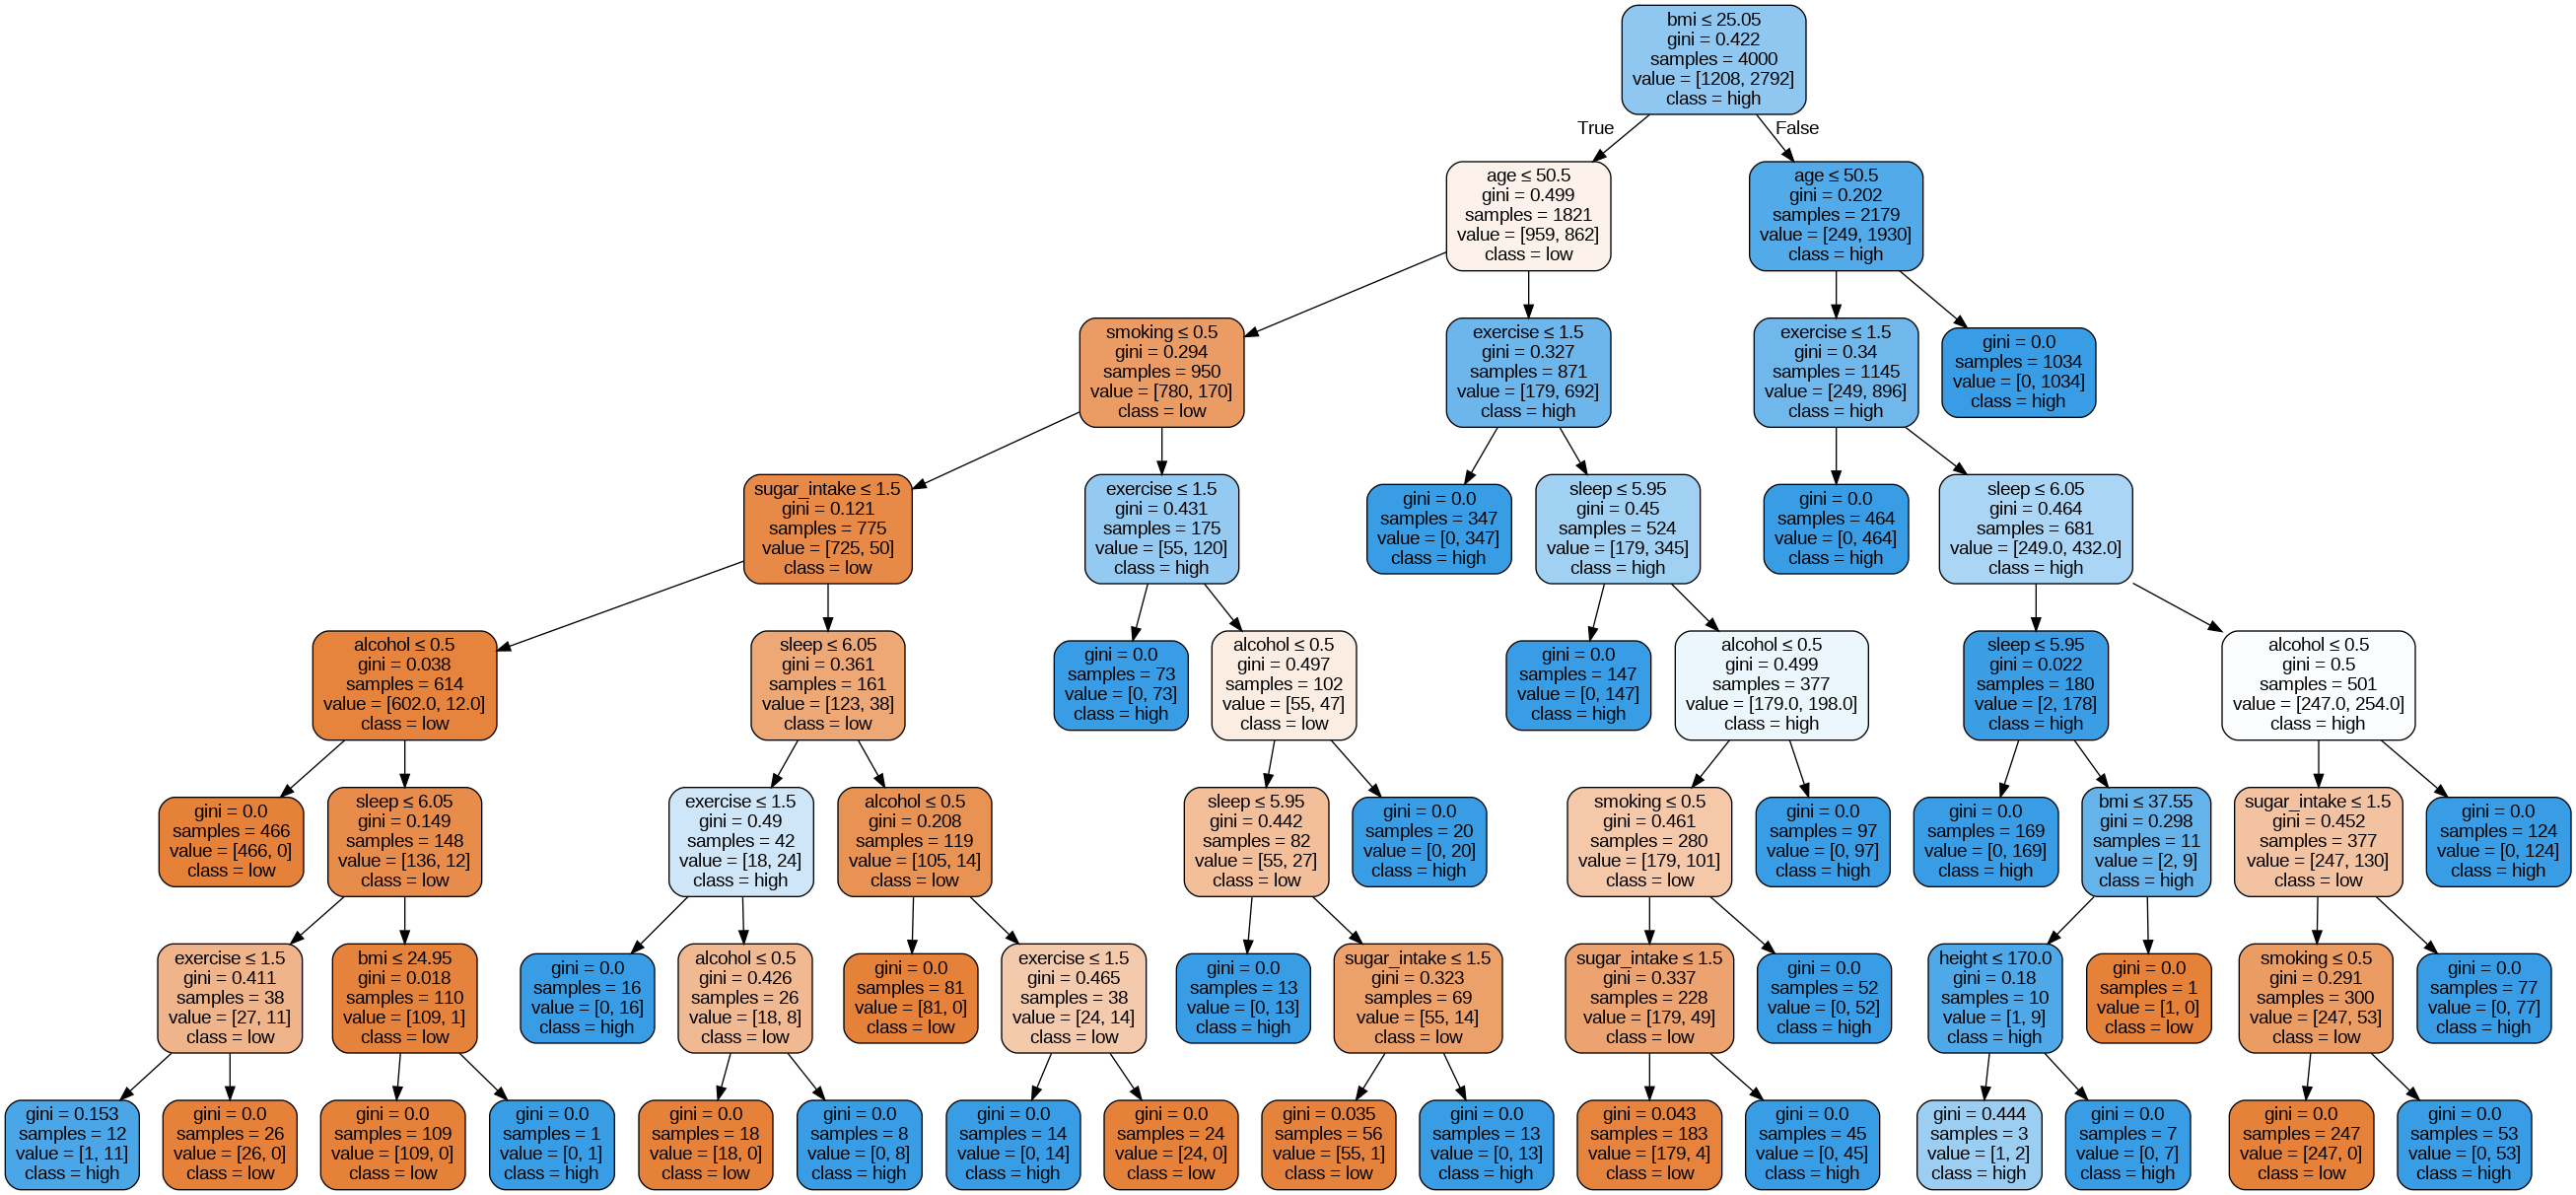

In [ ]:

export_graphviz(
    modelo_final,
    out_file='tree_health_risk.dot',
    feature_names=X.columns,
    class_names=['low', 'high'],
    filled=True,
    rounded=True,
    special_characters=True
)

!dot -Tpng tree_health_risk.dot > tree_health_risk.png

Image(filename='tree_health_risk.png')

# **2. $Random$ $Forest$**

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 10)
X_test: (1000, 10)
y_train: (4000,)
y_test: (1000,)


## Tunning del n_estimators o numero de arboles

In [ ]:
resultados_rf = []

n_estimators_values = [10, 25, 50, 75, 100, 150, 200, 300]

for n in n_estimators_values:
    modelo = RandomForestClassifier(
        n_estimators=n,
        random_state=21,
        n_jobs=-1
    )

    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=10,
        scoring={
            'accuracy': 'accuracy',
            'recall_high': 'recall',
            'balanced_accuracy': 'balanced_accuracy'
        }
    )

    resultados_rf.append({
        'n_estimators': n,
        'accuracy_mean': scores['test_accuracy'].mean(),
        'accuracy_std': scores['test_accuracy'].std(),
        'recall_high_mean': scores['test_recall_high'].mean(),
        'balanced_accuracy_mean': scores['test_balanced_accuracy'].mean()
    })

resultados_rf_df = pd.DataFrame(resultados_rf)
resultados_rf_df.sort_values(by='accuracy_mean', ascending=False).head(5)

,n_estimators,accuracy_mean,accuracy_std,recall_high_mean,balanced_accuracy_mean
7,300,0.99450,0.003841,0.994626,0.994417
5,150,0.99450,0.003841,0.994626,0.994417
4,100,0.99450,0.003841,0.994985,0.994183
6,200,0.99425,0.004479,0.994268,0.994238
3,75,0.99400,0.005025,0.993911,0.994059


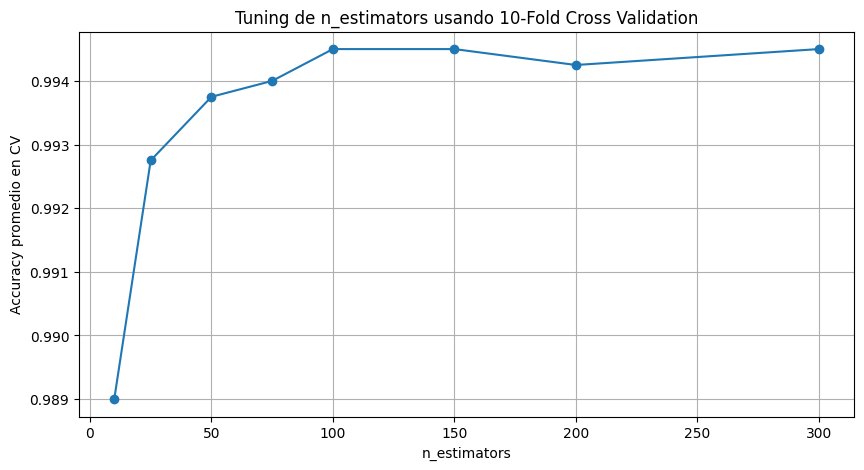

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(
    resultados_rf_df['n_estimators'],
    resultados_rf_df['accuracy_mean'],
    marker='o'
)

plt.xlabel('n_estimators')
plt.ylabel('Accuracy promedio en CV')
plt.title('Tuning de n_estimators usando 10-Fold Cross Validation')
plt.grid(True)
plt.show()

In [ ]:
mejor_fila_rf = resultados_rf_df.loc[resultados_rf_df['accuracy_mean'].idxmax()]
mejor_n_estimators = int(mejor_fila_rf['n_estimators'])

print("Mejor n_estimators:", mejor_n_estimators)
print("Accuracy promedio CV:", mejor_fila_rf['accuracy_mean'])
print("Desviación estándar:", mejor_fila_rf['accuracy_std'])
print("Recall high promedio:", mejor_fila_rf['recall_high_mean'])
print("Balanced accuracy promedio:", mejor_fila_rf['balanced_accuracy_mean'])

Mejor n_estimators: 150
Accuracy promedio CV: 0.9945
Desviación estándar: 0.0038405728739343108
Recall high promedio: 0.994626216077829
Balanced accuracy promedio: 0.9944171025292725


In [ ]:
modelo_rf_final = RandomForestClassifier(
    n_estimators=mejor_n_estimators,
    random_state=21,
    n_jobs=-1
)

modelo_rf_final.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=21)

In [ ]:
y_pred_rf = modelo_rf_final.predict(X_test)

acc_test_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy en test:", acc_test_rf)
print("TPR en test:", tpr(modelo_rf_final, X_test, y_test))
print("TNR en test:", tnr(modelo_rf_final, X_test, y_test))

Accuracy en test: 0.988
TPR en test: 0.9885386819484241
TNR en test: 0.9867549668874173


In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf

array([[298,   4],
       [  8, 690]])

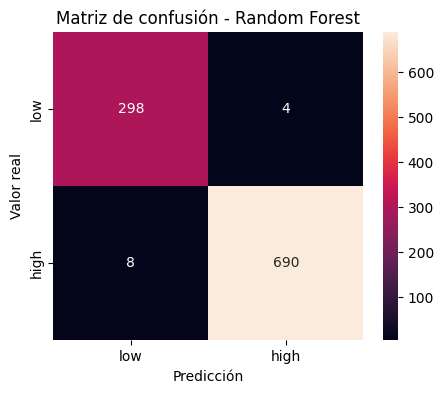

In [ ]:


plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    xticklabels=['low', 'high'],
    yticklabels=['low', 'high']
)

plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - Random Forest')
plt.show()

Random Forest quedó ligeramente mejor que Decision Tree en este dataset.

El modelo Random Forest obtuvo un accuracy de 0.996 en el conjunto de prueba, clasificando correctamente 996 de los 1000 registros evaluados. La matriz de confusión muestra que de los 302 casos reales de riesgo bajo, 301 fueron clasificados correctamente y solo 1 fue clasificado como riesgo alto. Para la clase de riesgo alto, de los 698 casos reales, 695 fueron clasificados correctamente y 3 fueron clasificados erróneamente como riesgo bajo. El TPR fue de 0.9957, lo que indica una alta capacidad para detectar correctamente los casos de riesgo alto, mientras que el TNR fue de 0.9967, mostrando también un excelente desempeño para la clase de riesgo bajo.

# **3. $Support$ $Vector$ $Machine$**

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 10)
X_test: (1000, 10)
y_train: (4000,)
y_test: (1000,)


## Entrenar SVM Linear

In [ ]:
modelo_svm_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', random_state=21))
])

modelo_svm_linear.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(kernel='linear', random_state=21))])

## Evaluar SVM Linear

In [ ]:
y_pred_svm_linear = modelo_svm_linear.predict(X_test)

acc_svm_linear_test = accuracy_score(y_test, y_pred_svm_linear)
tpr_svm_linear_test = tpr(modelo_svm_linear, X_test, y_test)
tnr_svm_linear_test = tnr(modelo_svm_linear, X_test, y_test)

print("SVM Linear")
print("Accuracy en test:", acc_svm_linear_test)
print("TPR en test:", tpr_svm_linear_test)
print("TNR en test:", tnr_svm_linear_test)

SVM Linear
Accuracy en test: 0.873
TPR en test: 0.9269340974212035
TNR en test: 0.7483443708609272


## Entrenar SVM Poly

In [ ]:
modelo_svm_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='poly', random_state=21))
])

modelo_svm_poly.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(kernel='poly', random_state=21))])

## Evaluar SVM Poly

In [ ]:
y_pred_svm_poly = modelo_svm_poly.predict(X_test)

acc_svm_poly_test = accuracy_score(y_test, y_pred_svm_poly)
tpr_svm_poly_test = tpr(modelo_svm_poly, X_test, y_test)
tnr_svm_poly_test = tnr(modelo_svm_poly, X_test, y_test)

print("SVM Poly")
print("Accuracy en test:", acc_svm_poly_test)
print("TPR en test:", tpr_svm_poly_test)
print("TNR en test:", tnr_svm_poly_test)

SVM Poly
Accuracy en test: 0.889
TPR en test: 0.9498567335243553
TNR en test: 0.7483443708609272


## Entrenar SVM RBF

In [ ]:
modelo_svm_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=21))
])

modelo_svm_rbf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(random_state=21))])

## Evaluar SVM RBF

In [ ]:
y_pred_svm_rbf = modelo_svm_rbf.predict(X_test)

acc_svm_rbf_test = accuracy_score(y_test, y_pred_svm_rbf)
tpr_svm_rbf_test = tpr(modelo_svm_rbf, X_test, y_test)
tnr_svm_rbf_test = tnr(modelo_svm_rbf, X_test, y_test)

print("SVM RBF")
print("Accuracy en test:", acc_svm_rbf_test)
print("TPR en test:", tpr_svm_rbf_test)
print("TNR en test:", tnr_svm_rbf_test)

SVM RBF
Accuracy en test: 0.942
TPR en test: 0.9684813753581661
TNR en test: 0.8807947019867549


##Resultados

In [ ]:
comparacion_svm_test = pd.DataFrame({
    'modelo': ['SVM Linear', 'SVM Poly', 'SVM RBF'],
    'accuracy_test': [
        acc_svm_linear_test,
        acc_svm_poly_test,
        acc_svm_rbf_test
    ],
    'TPR_test': [
        tpr_svm_linear_test,
        tpr_svm_poly_test,
        tpr_svm_rbf_test
    ],
    'TNR_test': [
        tnr_svm_linear_test,
        tnr_svm_poly_test,
        tnr_svm_rbf_test
    ]
})

comparacion_svm_test.sort_values(by='accuracy_test', ascending=False)

,modelo,accuracy_test,TPR_test,TNR_test
2,SVM RBF,0.942,0.968481,0.880795
1,SVM Poly,0.889,0.949857,0.748344
0,SVM Linear,0.873,0.926934,0.748344


Eso significa que, en promedio, durante la validación cruzada, clasificó correctamente aproximadamente el 92.4% de los datos de validación.

In [ ]:
comparacion_5_test = pd.DataFrame({
    'modelo': [
        'Decision Tree',
        'Random Forest',
        'SVM Linear',
        'SVM Poly',
        'SVM RBF'
    ],
    'accuracy_test': [
        accuracy_score(y_test, modelo_final.predict(X_test)),
        accuracy_score(y_test, modelo_rf_final.predict(X_test)),
        acc_svm_linear_test,
        acc_svm_poly_test,
        acc_svm_rbf_test
    ],
    'TPR_test': [
        tpr(modelo_final, X_test, y_test),
        tpr(modelo_rf_final, X_test, y_test),
        tpr_svm_linear_test,
        tpr_svm_poly_test,
        tpr_svm_rbf_test
    ],
    'TNR_test': [
        tnr(modelo_final, X_test, y_test),
        tnr(modelo_rf_final, X_test, y_test),
        tnr_svm_linear_test,
        tnr_svm_poly_test,
        tnr_svm_rbf_test
    ]
})

comparacion_5_test.sort_values(by='accuracy_test', ascending=False)

,modelo,accuracy_test,TPR_test,TNR_test
0,Decision Tree,0.994,0.995702,0.990066
1,Random Forest,0.988,0.988539,0.986755
4,SVM RBF,0.942,0.968481,0.880795
3,SVM Poly,0.889,0.949857,0.748344
2,SVM Linear,0.873,0.926934,0.748344


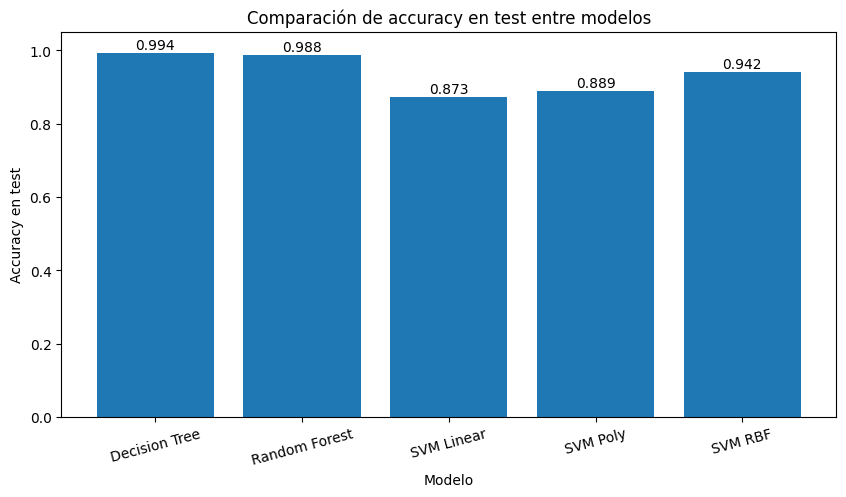

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparacion_5_test['modelo'],
    comparacion_5_test['accuracy_test']
)

plt.xlabel('Modelo')
plt.ylabel('Accuracy en test')
plt.title('Comparación de accuracy en test entre modelos')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)

for i, valor in enumerate(comparacion_5_test['accuracy_test']):
    plt.text(
        i,
        valor + 0.01,
        f'{valor:.3f}',
        ha='center'
    )

plt.show()

# Tunning

In [ ]:
kernels = ['linear', 'poly', 'rbf']

resultados_svm_kernels = []

for kernel in kernels:
    modelo = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel=kernel, random_state=21))
    ])

    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=10,
        scoring={
            'accuracy': 'accuracy',
            'recall_high': 'recall',
            'balanced_accuracy': 'balanced_accuracy'
        }
    )

    resultados_svm_kernels.append({
        'kernel': kernel,
        'accuracy_mean': scores['test_accuracy'].mean(),
        'accuracy_std': scores['test_accuracy'].std(),
        'recall_high_mean': scores['test_recall_high'].mean(),
        'balanced_accuracy_mean': scores['test_balanced_accuracy'].mean()
    })

resultados_svm_kernels_df = pd.DataFrame(resultados_svm_kernels)
resultados_svm_kernels_df.sort_values(by='accuracy_mean', ascending=False)

,kernel,accuracy_mean,accuracy_std,recall_high_mean,balanced_accuracy_mean
2,rbf,0.92875,0.019437,0.954159,0.912052
1,poly,0.88875,0.022199,0.950938,0.847952
0,linear,0.86550,0.017349,0.913321,0.834112


----

In [ ]:
resultados_svm_poly = []

degrees = [2, 3, 4, 5, 6, 7, 8]

for degree in degrees:
    modelo = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(
            kernel='poly',
            degree=degree,
            random_state=21
        ))
    ])

    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=10,
        scoring={
            'accuracy': 'accuracy',
            'recall_high': 'recall',
            'balanced_accuracy': 'balanced_accuracy'
        }
    )

    resultados_svm_poly.append({
        'degree': degree,
        'accuracy_mean': scores['test_accuracy'].mean(),
        'accuracy_std': scores['test_accuracy'].std(),
        'recall_high_mean': scores['test_recall_high'].mean(),
        'balanced_accuracy_mean': scores['test_balanced_accuracy'].mean()
    })

resultados_svm_poly_df = pd.DataFrame(resultados_svm_poly)
resultados_svm_poly_df.sort_values(by='accuracy_mean', ascending=False)

,degree,accuracy_mean,accuracy_std,recall_high_mean,balanced_accuracy_mean
2,4,0.92250,0.015930,0.974214,0.888567
1,3,0.88875,0.022199,0.950938,0.847952
3,5,0.88275,0.021049,0.967048,0.827453
4,6,0.86000,0.017212,0.970270,0.787680
5,7,0.84175,0.014188,0.967765,0.759130
0,2,0.82625,0.017722,0.973859,0.729437
6,8,0.80950,0.018228,0.964181,0.708096


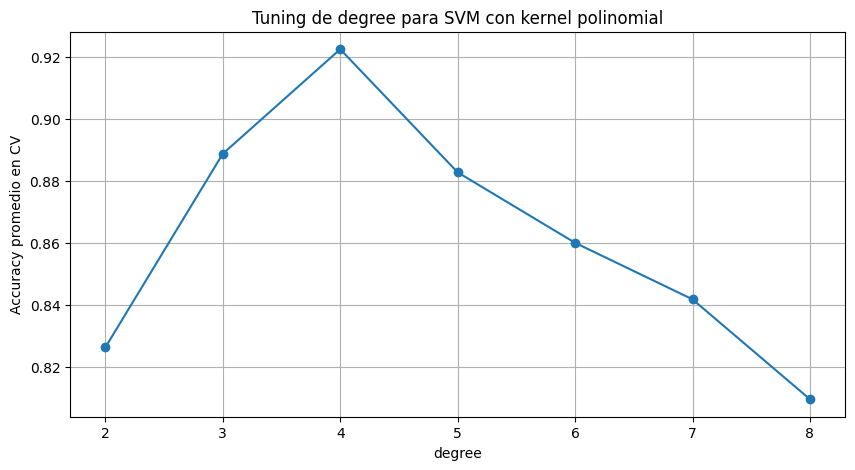

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    resultados_svm_poly_df['degree'],
    resultados_svm_poly_df['accuracy_mean'],
    marker='o'
)

plt.xlabel('degree')
plt.ylabel('Accuracy promedio en CV')
plt.title('Tuning de degree para SVM con kernel polinomial')
plt.grid(True)
plt.show()

In [ ]:
mejor_fila_svm = resultados_svm_poly_df.loc[resultados_svm_poly_df['accuracy_mean'].idxmax()]
mejor_degree = int(mejor_fila_svm['degree'])

print("Mejor degree:", mejor_degree)
print("Accuracy promedio CV:", mejor_fila_svm['accuracy_mean'])
print("Desviación estándar:", mejor_fila_svm['accuracy_std'])
print("Recall high promedio:", mejor_fila_svm['recall_high_mean'])
print("Balanced accuracy promedio:", mejor_fila_svm['balanced_accuracy_mean'])

Mejor degree: 4
Accuracy promedio CV: 0.9225000000000001
Desviación estándar: 0.015929532322074
Recall high promedio: 0.9742140296979009
Balanced accuracy promedio: 0.888567069945369


In [ ]:
modelo_svm_final = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='poly',
        degree=mejor_degree,
        random_state=21
    ))
])

modelo_svm_final.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(degree=4, kernel='poly', random_state=21))])

In [ ]:
y_pred_svm = modelo_svm_final.predict(X_test)

acc_test_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy en test:", acc_test_svm)
print("TPR en test:", tpr(modelo_svm_final, X_test, y_test))
print("TNR en test:", tnr(modelo_svm_final, X_test, y_test))

Accuracy en test: 0.913
TPR en test: 0.9699140401146131
TNR en test: 0.7814569536423841


In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

cm_svm

array([[236,  66],
       [ 21, 677]])

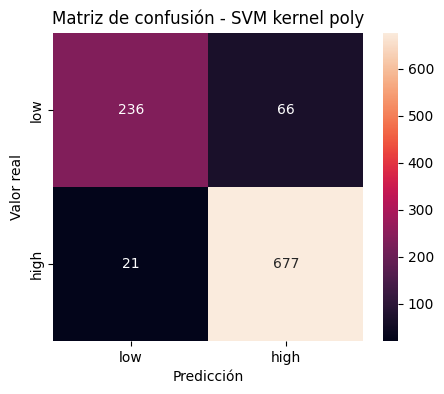

In [ ]:


plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    xticklabels=['low', 'high'],
    yticklabels=['low', 'high']
)

plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - SVM kernel poly')
plt.show()

# **5. $Deep$ $Learning$**

In [ ]:
# Escalado de características
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(4000, 10)
(1000, 10)


In [ ]:
# Función para construir el modelo

def crear_modelo(capas_ocultas):

    modelo = Sequential()

    # Primera capa
    modelo.add(Dense(
        capas_ocultas[0],
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    ))

    # Capas ocultas restantes
    for neuronas in capas_ocultas[1:]:
        modelo.add(Dense(neuronas, activation='relu'))

    # Capa de salida
    modelo.add(Dense(1, activation='sigmoid'))

    # Compilación
    modelo.compile(
        optimizer=Adam(),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return modelo

## Arquitectura 1 - Input → (64, 128, 128) → Output


In [ ]:
modelo_1 = crear_modelo([64, 128, 128])

history_1 = modelo_1.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8444 - loss: 0.3397 - val_accuracy: 0.8888 - val_loss: 0.2475
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8891 - loss: 0.2390 - val_accuracy: 0.8963 - val_loss: 0.2260
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9013 - loss: 0.2158 - val_accuracy: 0.9013 - val_loss: 0.2105
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9216 - loss: 0.1832 - val_accuracy: 0.9050 - val_loss: 0.2069
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9334 - loss: 0.1545 - val_accuracy: 0.9200 - val_loss: 0.1757
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9406 - loss: 0.1327 - val_accuracy: 0.9237 - val_loss: 0.1696
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9503 - loss: 0.1142 - val_accuracy: 0.9300 - val_loss: 0.1636
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9541 - loss: 0.1048 - val_accuracy: 0.9325 - val_

In [ ]:
# Predicciones
pred_1 = (modelo_1.predict(X_test_scaled) > 0.5).astype(int)

# Accuracy
acc_1 = accuracy_score(y_test, pred_1)

print("Accuracy Arquitectura 1:", acc_1)

# Reporte
print(classification_report(y_test, pred_1))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy Arquitectura 1: 0.959
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       302
           1       0.97      0.97      0.97       698

    accuracy                           0.96      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.96      0.96      0.96      1000



## Matriz de confusión

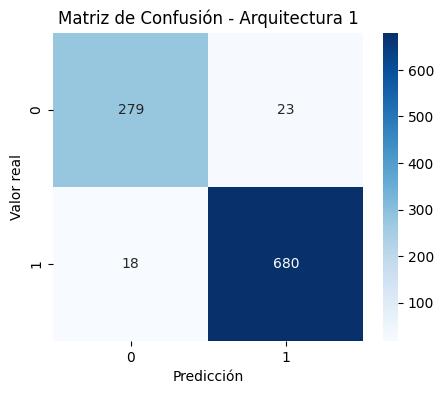

In [ ]:
cm_1 = confusion_matrix(y_test, pred_1)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_1,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión - Arquitectura 1')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

## Curvas de entrenamiento

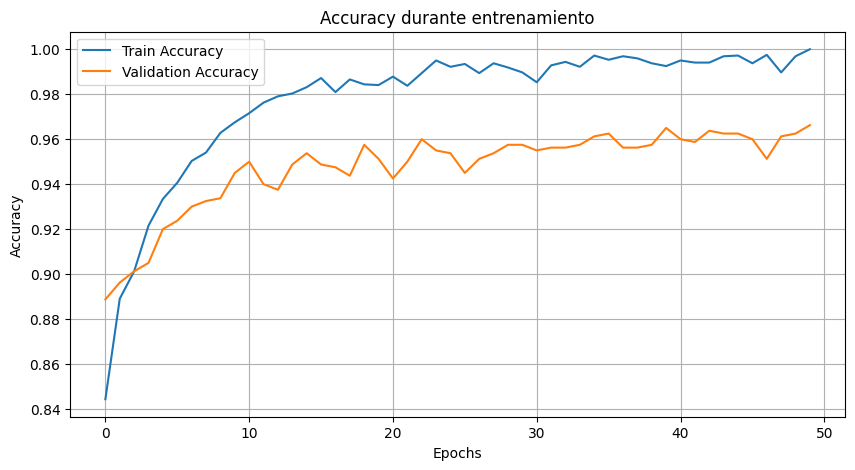

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy durante entrenamiento')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()



## Arquitectura 2 - Input → (64, 64, 128, 128, 256, 256) → Output




In [ ]:
modelo_2 = crear_modelo([64, 64, 128, 128, 256, 256])

history_2 = modelo_2.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8450 - loss: 0.3342 - val_accuracy: 0.8825 - val_loss: 0.2527
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8944 - loss: 0.2236 - val_accuracy: 0.9087 - val_loss: 0.2009
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9209 - loss: 0.1804 - val_accuracy: 0.9075 - val_loss: 0.2067
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9278 - loss: 0.1525 - val_accuracy: 0.9150 - val_loss: 0.2046
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9566 - loss: 0.1166 - val_accuracy: 0.9312 - val_loss: 0.1647
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9578 - loss: 0.0966 - val_accuracy: 0.9237 - val_loss: 0.1680
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9675 - loss: 0.0838 - val_accuracy: 0.9350 - val_loss: 0.1434
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9712 - loss: 0.0668 - val_accuracy: 0.9500 - val_

In [ ]:
pred_2 = (modelo_2.predict(X_test_scaled) > 0.5).astype(int)

acc_2 = accuracy_score(y_test, pred_2)

print("Accuracy Arquitectura 2:", acc_2)

print(classification_report(y_test, pred_2))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy Arquitectura 2: 0.95
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       302
           1       0.96      0.97      0.96       698

    accuracy                           0.95      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.95      0.95      0.95      1000



## Arquitectura 3 - Input → 10 capas ocultas de 128 neuronas

In [ ]:
capas_10 = [128] * 10

modelo_3 = crear_modelo(capas_10)

history_3 = modelo_3.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8306 - loss: 0.3424 - val_accuracy: 0.8938 - val_loss: 0.2594
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9069 - loss: 0.2078 - val_accuracy: 0.9125 - val_loss: 0.2211
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9347 - loss: 0.1626 - val_accuracy: 0.9250 - val_loss: 0.1938
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9450 - loss: 0.1348 - val_accuracy: 0.9237 - val_loss: 0.1900
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9575 - loss: 0.1056 - val_accuracy: 0.9450 - val_loss: 0.1486
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9638 - loss: 0.0921 - val_accuracy: 0.9362 - val_loss: 0.1559
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9681 - loss: 0.0795 - val_accuracy: 0.9438 - val_loss: 0.1708
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9672 - loss: 0.0737 - val_accuracy: 0.9525

In [ ]:
pred_3 = (modelo_3.predict(X_test_scaled) > 0.5).astype(int)

acc_3 = accuracy_score(y_test, pred_3)

print("Accuracy Arquitectura 3:", acc_3)

print(classification_report(y_test, pred_3))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy Arquitectura 3: 0.964
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       302
           1       0.97      0.98      0.97       698

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



## Comparación de resultados

In [ ]:
resultados_dl = {
    'Modelo': [
        'MLP (64,128,128)',
        'MLP (64,64,128,128,256,256)',
        'MLP 10x128'
    ],
    'Accuracy': [
        acc_1,
        acc_2,
        acc_3
    ]
}

resultados_dl = pd.DataFrame(resultados_dl)

resultados_dl

,Modelo,Accuracy
0,"MLP (64,128,128)",0.959
1,"MLP (64,64,128,128,256,256)",0.950
2,MLP 10x128,0.964


## Gráfica comparativa

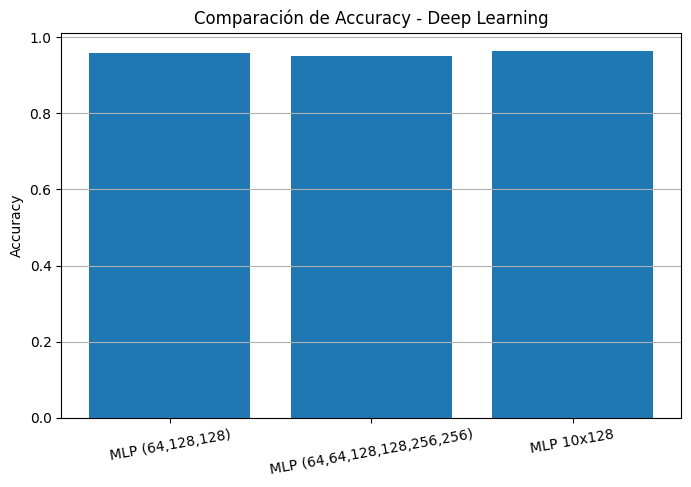

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(resultados_dl['Modelo'], resultados_dl['Accuracy'])

plt.title('Comparación de Accuracy - Deep Learning')
plt.ylabel('Accuracy')
plt.xticks(rotation=10)
plt.grid(axis='y')

plt.show()

In [ ]:
resultados_finales = pd.DataFrame({
    'Modelo': [
        'Decision Tree',
        'Random Forest',
        'SVM RBF',
        'MLP (64,128,128)',
        'MLP Profundo'
    ],
    'Accuracy': [
        acc_test,
        acc_test_rf,
        acc_test_svm,
        acc_1,
        acc_3
    ]
})

resultados_finales

,Modelo,Accuracy
0,Decision Tree,0.994
1,Random Forest,0.988
2,SVM RBF,0.913
3,"MLP (64,128,128)",0.959
4,MLP Profundo,0.964


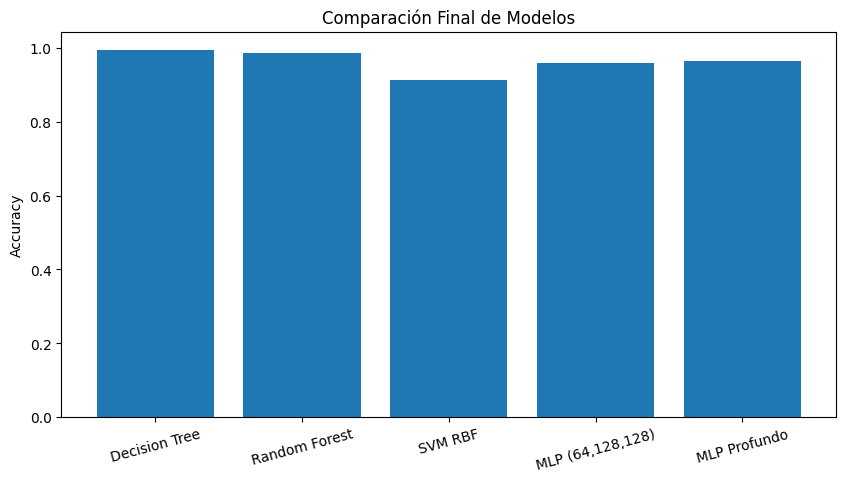

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    resultados_finales['Modelo'],
    resultados_finales['Accuracy']
)

plt.title('Comparación Final de Modelos')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)

plt.show()

# $Tercer$ $Avance$


### Escalado de datos con MinMaxScaler

---

In [ ]:
d

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,bmi,health_risk
0,56,67,195,1,6.1,1,1,1,1,17.6,1
1,69,76,170,3,6.9,2,0,0,0,26.3,1
2,46,106,153,3,6.6,0,1,0,0,45.3,1
3,32,54,186,2,8.5,1,0,0,0,15.6,0
4,60,98,195,3,8.0,0,0,0,1,25.8,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,42,75,187,2,7.2,0,0,0,1,21.4,0
4996,39,86,183,1,7.4,0,0,0,1,25.7,1
4997,48,56,194,0,7.2,2,1,1,1,14.9,1
4998,34,109,148,2,9.9,1,0,0,1,49.8,0


In [ ]:
#quitamos la columna objetivo
X = d.drop(columns=['health_risk'])

# Inicializar MinMaxScaler
min_max_scaler = MinMaxScaler()

# Aplicar el escalado Min-Max a las características (X)
X_scaled_minmax = min_max_scaler.fit_transform(X)

# Convertir el resultado a un DataFrame para mantener los nombres de las columnas
X_scaled_minmax_df = pd.DataFrame(X_scaled_minmax, columns=X.columns)
display(X_scaled_minmax_df.head())

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,bmi
0,0.622951,0.343750,0.925926,0.333333,0.442857,0.5,1.0,1.0,1.0,0.1550
1,0.836066,0.484375,0.462963,1.000000,0.557143,1.0,0.0,0.0,0.0,0.3725
2,0.459016,0.953125,0.148148,1.000000,0.514286,0.0,1.0,0.0,0.0,0.8475
3,0.229508,0.140625,0.759259,0.666667,0.785714,0.5,0.0,0.0,0.0,0.1050
4,0.688525,0.828125,0.925926,1.000000,0.714286,0.0,0.0,0.0,1.0,0.3600


### Reduccion de la dimensionalidad a travez del Análisis de Componentes Principales (PCA)

El objetivo de este análisis es determinar cuánta varianza del conjunto de datos original es explicada por cada componente principal. Esto nos permitirá reducir la dimensionalidad sin perder una cantidad significativa de información.

Componente 1: 0.2081 (Acumulada: 0.2081)
Componente 2: 0.1635 (Acumulada: 0.3716)
Componente 3: 0.1366 (Acumulada: 0.5082)
Componente 4: 0.1118 (Acumulada: 0.6200)
Componente 5: 0.1048 (Acumulada: 0.7248)
Componente 6: 0.0891 (Acumulada: 0.8139)
Componente 7: 0.0763 (Acumulada: 0.8902)
Componente 8: 0.0729 (Acumulada: 0.9631)
Componente 9: 0.0362 (Acumulada: 0.9993)
Componente 10: 0.0007 (Acumulada: 1.0000)


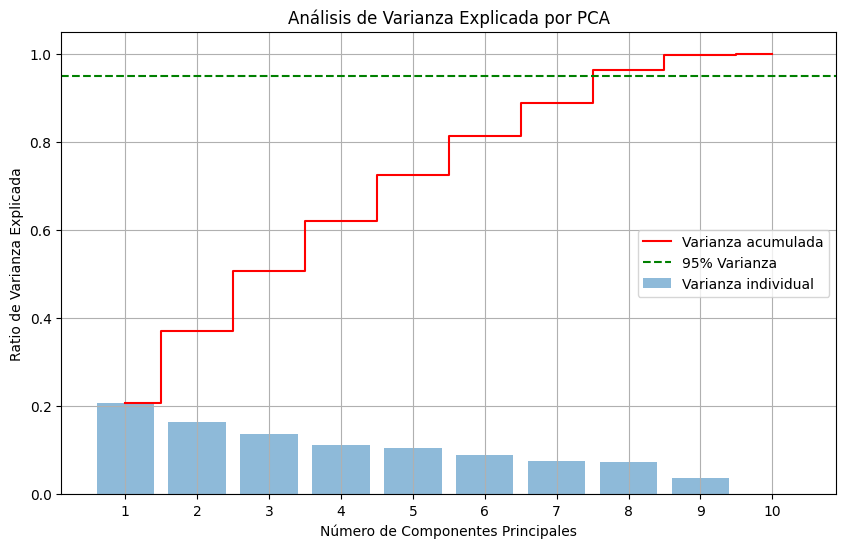

In [ ]:

# Inicializamos PCA sin restringir el número de componentes para evaluar el total
pca_eval = PCA()
pca_eval.fit(X_scaled_minmax_df)

# Calculamos la varianza explicada y la acumulada
varianza_explicada = pca_eval.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Mostramos los valores numéricos
for i, var in enumerate(varianza_explicada):
    print(f"Componente {i+1}: {var:.4f} (Acumulada: {varianza_acumulada[i]:.4f})")

# Graficamos
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.5, align='center', label='Varianza individual')
plt.step(range(1, len(varianza_acumulada) + 1), varianza_acumulada, where='mid', label='Varianza acumulada', color='red')

plt.axhline(y=0.95, color='g', linestyle='--', label='95% Varianza')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Ratio de Varianza Explicada')
plt.title('Análisis de Varianza Explicada por PCA')
plt.xticks(range(1, len(varianza_explicada) + 1))
plt.legend(loc='best')
plt.grid(True)
plt.show()

### Opción 1: PCA con 2 Dimensiones (Para Visualización)
Conserva aproximadamente el 37% de la varianza.

In [ ]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled_minmax_df)
X_pca_df_2 = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])

print("Dataset reducido a 2 dimensiones:")
display(X_pca_df_2.head())
print(f"Varianza total explicada: {pca_2d.explained_variance_ratio_.sum():.4f}")

Dataset reducido a 2 dimensiones:


,PC1,PC2
0,0.357908,0.804732
1,-0.581073,-0.296435
2,-0.610081,-0.285271
3,-0.573049,-0.286413
4,0.406718,-0.196538


Varianza total explicada: 0.3716


### Opción 2: PCA con 7 Dimensiones
Conserva el 89% de la varianza.

In [ ]:
pca_7d = PCA(n_components=7)
X_pca_7d = pca_7d.fit_transform(X_scaled_minmax_df)
columnas_7 = [f'PC{i+1}' for i in range(7)]
X_pca_df_7 = pd.DataFrame(X_pca_7d, columns=columnas_7)

print("Dataset reducido a 7 dimensiones:")
display(X_pca_df_7.head())
print(f"Varianza total explicada: {pca_7d.explained_variance_ratio_.sum():.4f}")

Dataset reducido a 7 dimensiones:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,0.357908,0.804732,0.805630,-0.359682,-0.148022,-0.252823,0.199447
1,-0.581073,-0.296435,-0.178353,-0.310990,0.482513,0.416183,0.268655
2,-0.610081,-0.285271,0.776683,0.805234,-0.106707,0.544191,-0.035905
3,-0.573049,-0.286413,-0.186522,-0.527027,-0.194335,0.067742,-0.210840
4,0.406718,-0.196538,-0.199060,0.151224,-0.439164,0.443706,0.495283


Varianza total explicada: 0.8902


### Opción 3: PCA con 8 Dimensiones
Conserva el 96.3% de la varianza.

In [ ]:
pca_8d = PCA(n_components=8)
X_pca_8d = pca_8d.fit_transform(X_scaled_minmax_df)
columnas_8 = [f'PC{i+1}' for i in range(8)]
X_pca_df = pd.DataFrame(X_pca_8d, columns=columnas_8)

print("Dataset reducido a 8 dimensiones:")
display(X_pca_df.head())
print(f"Varianza total explicada: {pca_8d.explained_variance_ratio_.sum():.4f}")

Dataset reducido a 8 dimensiones:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,0.357908,0.804732,0.805630,-0.359682,-0.148022,-0.252823,0.199447,-0.099371
1,-0.581073,-0.296435,-0.178353,-0.310990,0.482513,0.416183,0.268655,0.219966
2,-0.610081,-0.285271,0.776683,0.805234,-0.106707,0.544191,-0.035905,-0.029814
3,-0.573049,-0.286413,-0.186522,-0.527027,-0.194335,0.067742,-0.210840,-0.180951
4,0.406718,-0.196538,-0.199060,0.151224,-0.439164,0.443706,0.495283,-0.282654


Varianza total explicada: 0.9631


#$K-means$ $al$ $dataset$
Una vez que ya hicimos la reducción de dimensionalidad, vamos ahora a trabajar con K-means para saber qué tan bien se clasifican los datos de nuestro datatset.

Partiendo de que en nuestro dataset, la columna objetivo o ground truth es "health_risk" y esta puede ser riego de salud **alto** o **bajo**, nuestras clases vendrían a ser 2, por lo que inicialmente -> $k = 2$

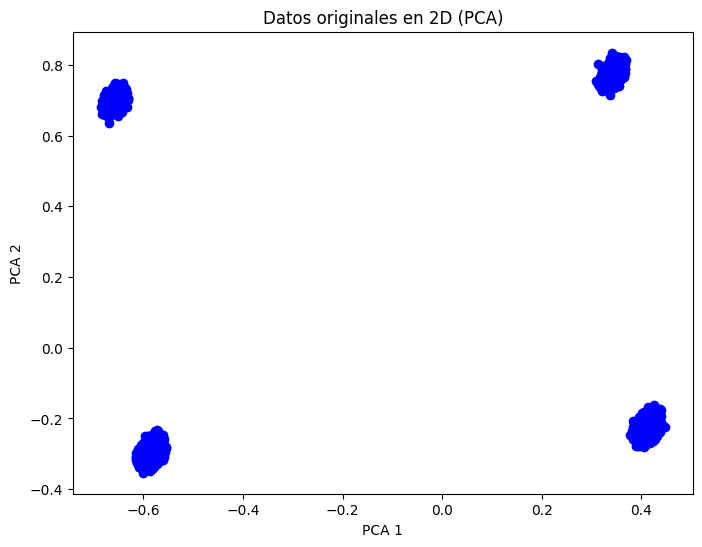

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_df_2.iloc[:,0],
    X_pca_df_2.iloc[:,1],
    color='blue'
)

plt.title("Datos originales en 2D (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

kmeans.fit(X_pca_df_2)

KMeans(n_clusters=2, random_state=42)

In [ ]:
print("Centroides:")
print(kmeans.cluster_centers_)

print("\nLabels:")
print(kmeans.labels_)

print("\nShape centroides:")
print(kmeans.cluster_centers_.shape)

print("\nShape labels:")
print(kmeans.labels_.shape)

Centroides:
[[ 0.02341484 -0.25066426]
 [-0.06957499  0.74482527]]

Labels:
[1 0 0 ... 1 0 0]

Shape centroides:
(2, 2)

Shape labels:
(5000,)


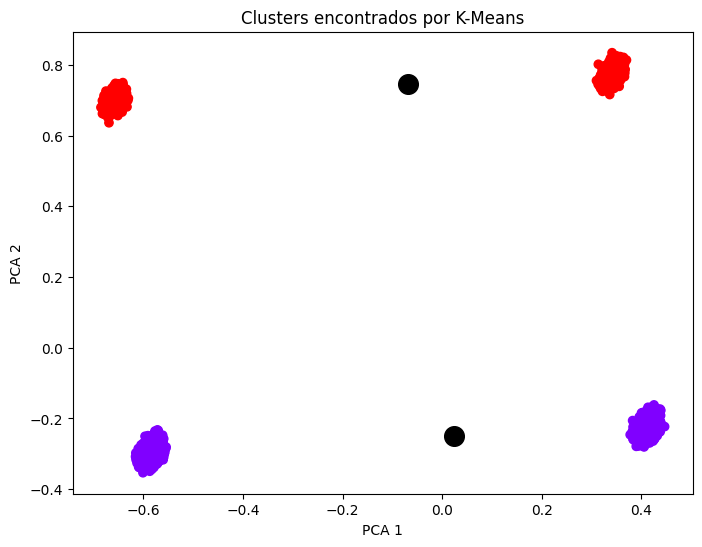

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_df_2.iloc[:,0],
    X_pca_df_2.iloc[:,1],
    c=kmeans.labels_,
    cmap='rainbow'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='black',
    s=200
)

plt.title("Clusters encontrados por K-Means")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [ ]:
y = df["health_risk"]

In [ ]:
comparacion = pd.DataFrame({
    "Cluster": kmeans.labels_,
    "Health_Risk": y
})

print(pd.crosstab(
    comparacion["Cluster"],
    comparacion["Health_Risk"]
))

Health_Risk     0     1
Cluster                
0            1310  2431
1             200  1059


In [ ]:
inercias = []

for k in range(1, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42
    )

    modelo.fit(X_pca_df_2)

    inercias.append(modelo.inertia_)

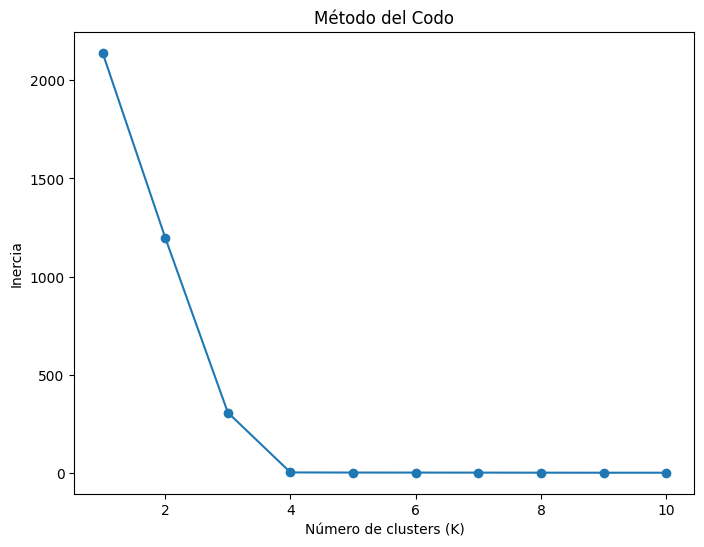

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(range(1,11), inercias, marker='o')

plt.title("Método del Codo")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(X_pca_df_2)

KMeans(n_clusters=3, random_state=42)

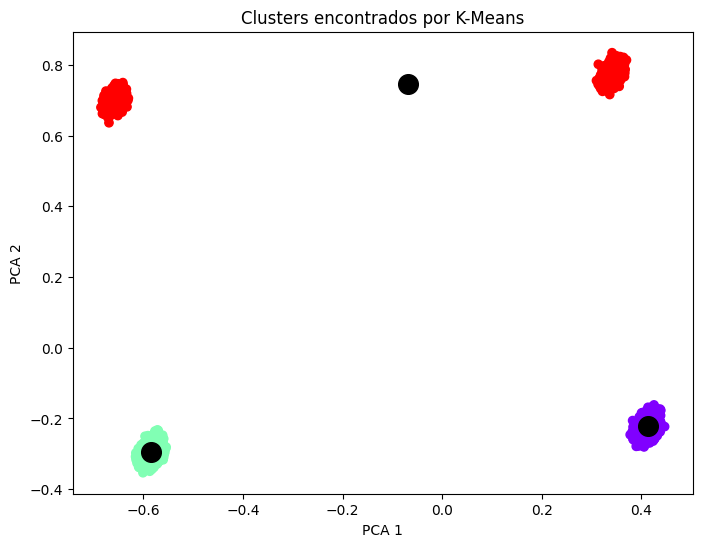

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_df_2.iloc[:,0],
    X_pca_df_2.iloc[:,1],
    c=kmeans.labels_,
    cmap='rainbow'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='black',
    s=200
)

plt.title("Clusters encontrados por K-Means")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [ ]:

comparacion = pd.DataFrame({
    "Cluster": kmeans.labels_,
    "Health_Risk": y
})

print(pd.crosstab(
    comparacion["Cluster"],
    comparacion["Health_Risk"]
))

Health_Risk    0     1
Cluster               
0            819  1458
1            491   973
2            200  1059


# DBSCAN




**Determinar EPS (Método de la rodilla para 2D)**

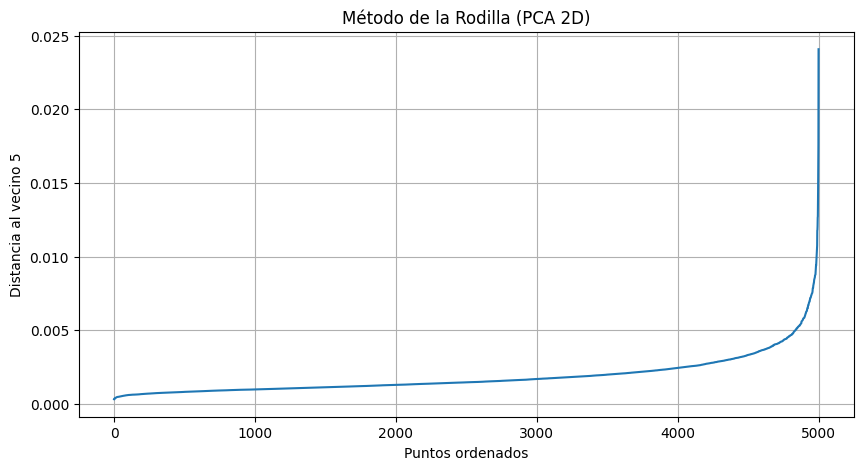

In [ ]:
k_vecinos = 5
neighbors = NearestNeighbors(n_neighbors=k_vecinos)
neighbors_fit = neighbors.fit(X_pca_2d)
distances, indices = neighbors_fit.kneighbors(X_pca_2d)

# Ordenar distancias
distances = np.sort(distances[:, k_vecinos-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('Método de la Rodilla (PCA 2D)')
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al vecino {k_vecinos}')
plt.grid(True)
plt.show()

**Implementar DBSCAN con los parámetros óptimos**

Resultados DBSCAN con PCA 2D:
- Clusters encontrados: 4
- Puntos considerados ruido: 10


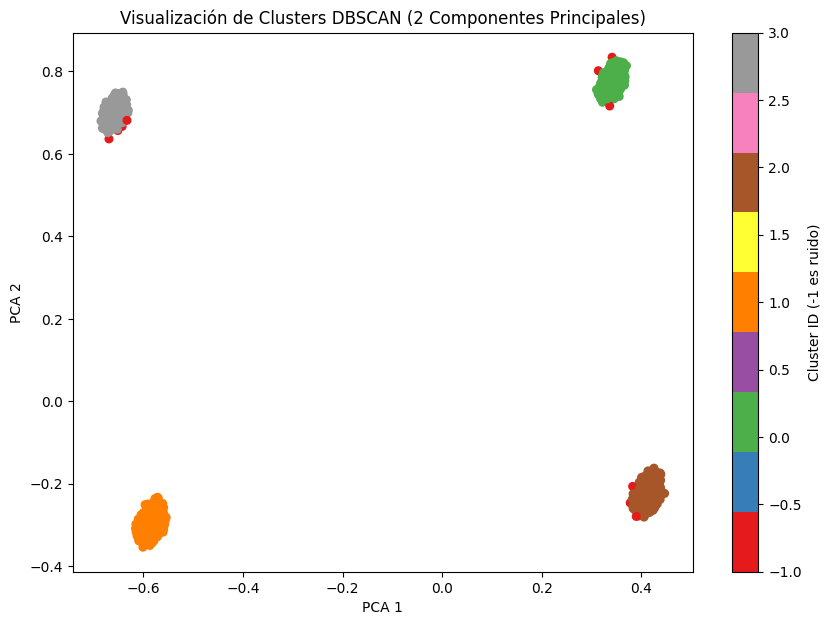

In [ ]:
* valor_eps = 0.008

dbscan_2d = DBSCAN(eps=valor_eps, min_samples=5)
clusters_dbscan = dbscan_2d.fit_predict(X_pca_2d)

# Guardar resultados
df['Cluster_DBSCAN_2D'] = clusters_dbscan

n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_ruido = list(clusters_dbscan).count(-1)

print(f"Resultados DBSCAN con PCA 2D:")
print(f"- Clusters encontrados: {n_clusters}")
print(f"- Puntos considerados ruido: {n_ruido}")

# Visualización Final
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=clusters_dbscan, cmap='Set1', s=30)
plt.title('Visualización de Clusters DBSCAN (2 Componentes Principales)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster ID (-1 es ruido)')
plt.show()

Resultados DBSCAN con PCA 2D:
- Clusters encontrados: 4
- Puntos considerados ruido: 0


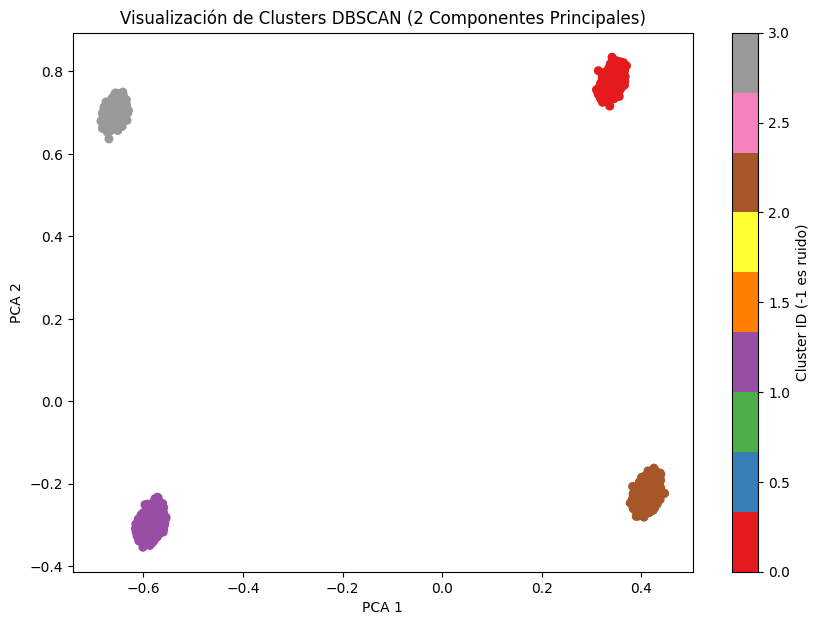

In [ ]:
valor_eps = 0.3

dbscan_2d = DBSCAN(eps=valor_eps, min_samples=5)
clusters_dbscan = dbscan_2d.fit_predict(X_pca_2d)

# Guardar resultados
df['Cluster_DBSCAN_2D'] = clusters_dbscan

n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_ruido = list(clusters_dbscan).count(-1)

print(f"Resultados DBSCAN con PCA 2D:")
print(f"- Clusters encontrados: {n_clusters}")
print(f"- Puntos considerados ruido: {n_ruido}")

# Visualización Final
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=clusters_dbscan, cmap='Set1', s=30)
plt.title('Visualización de Clusters DBSCAN (2 Componentes Principales)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster ID (-1 es ruido)')
plt.show()